In [96]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,List
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage,SystemMessage
from dotenv import load_dotenv
import re
import json

load_dotenv()

True

In [97]:
def trend_node(df:pd.DataFrame) -> dict:

    if len(df) < 200:
        raise ValueError(f"Not enough data for SMA 200 — only {len(df)} rows")

    # SMA 50 and 200
    df['SMA_50']  = ta.sma(df['Close'], length=50)
    df['SMA_200'] = ta.sma(df['Close'], length=200)

    # EMA 12 and 26
    df['EMA_12'] = ta.ema(df['Close'], length=12)
    df['EMA_26'] = ta.ema(df['Close'], length=26)

    # Cross signal
    df['above'] = (df['SMA_50'] > df['SMA_200']).astype(int)
    df['CrossEventSignal'] = df['above'].diff()

    # Bollinger Bands 
    bbands = ta.bbands(df['Close'], length=20, std=2)
    df['BB_lower'] = bbands.iloc[:, 0]   # BBL — lower band
    df['BB_mid']   = bbands.iloc[:, 1]   # BBM — middle band
    df['BB_upper'] = bbands.iloc[:, 2]   # BBU — upper band
    df['BB_width'] = bbands.iloc[:, 3]   # BBB — bandwidth
    df['BB_pct']   = bbands.iloc[:, 4]

    # Read the latest row for output
    latest = df.iloc[-1]
    cross_val = df['CrossEventSignal'].iloc[-1]

    # determine bb_signal
    if latest['BB_pct'] > 0.8:
        bb_signal =  "overbought"
    elif latest['BB_pct'] < 0.2:
        bb_signal ="oversold"
    else:
        bb_signal ="neutral"

    # Determine signal
    if cross_val == 1:
        cross_signal = "golden_cross"
    elif cross_val == -1:
        cross_signal = "death_cross"
    elif latest['SMA_50'] > latest['SMA_200']:
        cross_signal = "bullish"        # above but no fresh cross
    else:
        cross_signal = "bearish"        # below but no fresh cross

    return {
            # .item() strips the numpy wrapper
            "Name":"Trend",
            "sma_50":        round(latest['SMA_50'].item(), 2),
            "sma_200":       round(latest['SMA_200'].item(), 2),
            "ema_12":        round(latest['EMA_12'].item(), 2),
            "ema_26":        round(latest['EMA_26'].item(), 2),
            "cross_signal":  cross_signal,             
            "bb_lower":      round(latest['BB_lower'].item(), 2),
            "bb_upper":      round(latest['BB_upper'].item(), 2),          
            "bb_pct":        round(latest['BB_pct'].item(), 3),
            "bb_signal":     bb_signal ,
            "current_price": round(latest['Close'].item(), 2),
        }


In [98]:
def momentum_node(df:pd.DataFrame) -> dict:

    # RSI
    df['RSI_14'] = ta.rsi(df['Close'], length=14)

    # MACD — use iloc positions, not hardcoded names
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD']        = macd.iloc[:, 0]   # MACD line
    df['MACD_hist']   = macd.iloc[:, 1]   # histogram
    df['MACD_signal'] = macd.iloc[:, 2]   # signal line

    # Stoch — only 2 columns, no histogram
    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3, smooth_k=3)
    df['STOCH_k'] = stoch.iloc[:, 0]   # %K — fast line
    df['STOCH_d'] = stoch.iloc[:, 1]   # %D — slow signal line

    # ROC
    df['ROC_10'] = ta.roc(df['Close'], length=10)

    # Drop NaN rows that indicators couldn't compute yet
    df.dropna(inplace=True)

    latest = df.iloc[-1]

    # RSI interpretation
    rsi_val = round(float(latest['RSI_14']), 2)
    if rsi_val >= 70:
        rsi_signal = "overbought"
    elif rsi_val <= 30:
        rsi_signal = "oversold"
    else:
        rsi_signal = "neutral"

    # MACD interpretation
    macd_signal = "bullish" if latest['MACD_hist'] > 0 else "bearish"

    # Stoch interpretation
    stoch_k = round(float(latest['STOCH_k']), 2)
    if stoch_k >= 80:
        stoch_signal = "overbought"
    elif stoch_k <= 20:
        stoch_signal = "oversold"
    else:
        stoch_signal = "neutral"

    return {
        "Name":"Momentum",
        "rsi":          rsi_val,
        "rsi_signal":   rsi_signal,
        "macd":         round(float(latest['MACD']), 2),
        "macd_hist":    round(float(latest['MACD_hist']), 2),
        "macd_signal":  round(float(latest['MACD_signal']), 2),
        "macd_verdict": macd_signal,
        "stoch_k":      stoch_k,
        "stoch_d":      round(float(latest['STOCH_d']), 2),
        "stoch_signal": stoch_signal,
        "roc_10":       round(float(latest['ROC_10']), 2),
    }

In [99]:
def volume_node(df:pd.DataFrame) -> dict:
    df['OBV'] = ta.obv(df['Close'], df['Volume'])

    # 2. Volume vs Average Spike
    df['Vol_SMA_20'] = ta.sma(df['Volume'], length=20)
    # Then we divide today's volume by that average. 
    df['Vol_Spike_Ratio'] = df['Volume'] / df['Vol_SMA_20']

    # 3. VWAP (Volume Weighted Average Price)
    df['typical_price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['VP'] = df['typical_price'] * df['Volume']
    vwap_level = df['VP'].sum() / df['Volume'].sum()

    # 4. Accumulation / Distribution Line (ADL)
    df['ADL'] = ta.ad(df['High'], df['Low'], df['Close'], df['Volume'])

    latest = df.iloc[-1]

    vol_signal= "high" if latest['Vol_Spike_Ratio'] > 1.5 else "low" if latest['Vol_Spike_Ratio'] < 0.7 else "normal"
    obv_trend =  "accumulation" if float(latest['OBV']) > float(df['OBV'].iloc[-20]) else "distribution"
    
    return {
    "Name":"Volume",
    "obv":             round(float(latest['OBV']), 2),
    "adl":             round(float(latest['ADL']), 2),
    "vol_spike_ratio": round(float(latest['Vol_Spike_Ratio']), 3),
    "vwap_lvl":        round(float(vwap_level), 2),
    "vol_signal":vol_signal,
    "obv_trend": obv_trend
    }
    

In [100]:

def volatility_node(df:pd.DataFrame) -> dict:

    # 1. ATR (Average True Range) - 14 Day
    df['ATR_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

    # 2. Historical Volatility (30-day Annualized)
    # The industry standard: standard deviation of logarithmic returns multiplied by sqrt(252).
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Hist_Vol_30'] = df['Log_Ret'].rolling(window=30).std() * np.sqrt(252)

    # 3. 52-Week High / Low
    # A trading year has roughly 252 days. We use min_periods=1 so it works 
    # even if you only feed it 100 days of data, preventing NaN crashes.
    df['52W_High'] = df['Close'].rolling(window=252, min_periods=1).max()
    df['52W_Low'] = df['Close'].rolling(window=252, min_periods=1).min()

    latest = df.iloc[-1]

    vol_regime = "high" if latest['Hist_Vol_30'] > 0.3 else "low" if latest['Hist_Vol_30'] < 0.15 else "normal"
    pct_from_high = (latest['Close'] - latest['52W_High']) / latest['52W_High']
    pct_from_low  = (latest['Close'] - latest['52W_Low'])  / latest['52W_Low']

    return {
        "Name":"Volatality",
        "atr_14":            round(float(latest['ATR_14']), 2),
        "hist_vol":          round(float(latest['Hist_Vol_30']), 4),
        "high_52w":          round(float(latest['52W_High']), 2),
        "low_52w":           round(float(latest['52W_Low']), 2),
        "pct_from_52w_high": round(float(pct_from_high), 3), 
        "pct_from_52w_low":  round(float(pct_from_low), 3),
        "vol_regime" : vol_regime 
    }

In [101]:
def technical_agent_pipeline (ticker:str)->str:
    period="1y"
    df=yf.Ticker(ticker).history(period=period)

    if len(df) < 200:
        raise ValueError(f"Not enough data — only {len(df)} rows")
    
    trend      = trend_node(df)        
    momentum   = momentum_node(df)
    volume     = volume_node(df)
    volatility = volatility_node(df)
    sub_worker=f"{trend},{momentum},{volume},{volatility}"
    return sub_worker
    

In [102]:
report_writer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
)

In [103]:
class KeyLevels(BaseModel):
    resistance: float
    support: float


class TechnicalReport(BaseModel):
    ticker: str
    overall_signal: str          # "Bullish" | "Bearish" | "Neutral"
    confidence: float            # 0 to 1
    trend_verdict: str           # SMA cross, EMA, Bollinger interpretation
    momentum_verdict: str        # RSI, MACD, Stoch interpretation
    volume_verdict: str          # OBV, volume spike, ADL interpretation
    volatility_verdict: str      # ATR, hist_vol, 52w position interpretation
    key_signals: List[str]       # e.g. ["Golden cross confirmed", "RSI approaching overbought"]
    risks: List[str]             # e.g. ["RSI at 72 — overbought risk", "Volume declining on rally"]
    entry_zone: str              # e.g. "Wait for RSI pullback to 55 before entering"
    key_levels: KeyLevels        # resistance and support prices
    summary: str

In [104]:
class TechnicalState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    ticker: str
    result: str
    data: dict

In [105]:

def technical_Agent(state: TechnicalState)->TechnicalState:
    result = technical_agent_pipeline(state["ticker"])
    return {"data": result}

In [106]:
REPORT_SYSTEM_PROMPT = """You are a technical analysis expert. You will receive computed technical indicators for a stock. Your job is to interpret these signals and return a structured technical report.

INDICATOR GROUPS AND HOW TO READ THEM:

TREND (highest weight):
- cross_signal: "golden_cross" = strong bull, "death_cross" = strong bear, "bullish/bearish" = ongoing trend
- sma_50 vs sma_200: gap size shows trend strength
- ema_12 vs ema_26: short-term momentum direction
- bb_signal: "overbought" = near upper band, "oversold" = near lower band
- bb_pct: 0=at lower band, 0.5=middle, 1=at upper band

MOMENTUM (medium weight):
- rsi: >70 overbought, <30 oversold, 40-60 neutral
- rsi_signal: already interpreted for you
- macd_verdict: "bullish" = histogram above zero, "bearish" = below
- macd_hist: positive and growing = accelerating momentum
- stoch_signal: "overbought/oversold/neutral"
- roc_10: positive = price higher than 10 days ago, negative = lower

VOLUME (confirms trend):
- obv_trend: "accumulation" = smart money buying, "distribution" = smart money selling
- vol_signal: "high" = above average volume (confirms moves), "low" = weak conviction
- vol_spike_ratio: >1.5 = unusual volume, worth noting
- adl: rising = buying pressure, falling = selling pressure
- vwap_lvl: price above VWAP = bullish intraday bias

VOLATILITY (context only, not directional):
- atr_14: daily expected price range in currency units
- hist_vol: <0.15 = low vol, 0.15-0.30 = normal, >0.30 = high vol
- vol_regime: "low/normal/high"
- pct_from_52w_high: -0.05 = 5% below 52w high (near resistance)
- pct_from_52w_low: 0.40 = 40% above 52w low (well off bottom)

CONFLUENCE RULES:
- 4-5 indicators agree → high confidence verdict
- 2-3 indicators agree → medium confidence, note the conflict
- Trend + Volume agree but Momentum conflicts → note overbought/oversold risk
- Never give high confidence when trend and volume disagree

RETURN ONLY this JSON:
{
  "ticker": str,
  "overall_signal": "Bullish" | "Bearish" | "Neutral",
  "confidence": float (0 to 1),
  "trend_verdict": str (1-2 sentences on SMA cross, EMA, Bollinger),
  "momentum_verdict": str (1-2 sentences on RSI, MACD, Stoch),
  "volume_verdict": str (1-2 sentences on OBV, volume spike, ADL),
  "volatility_verdict": str (1-2 sentences on ATR, hist_vol, 52w position),
  "key_signals": [str],
  "risks": [str],
  "entry_zone": str (e.g. "Wait for RSI pullback to 55" or "Current price is valid entry"),
  "key_levels": {
    "resistance": float,
    "support": float
  },
  "summary": str (3-4 sentence overall technical verdict combining all groups)
}

Return ONLY valid JSON. No markdown fences, no extra text."""

In [107]:
def report_node(state: TechnicalState)->TechnicalState:
    data=state["data"]

    clean_messages = [
        SystemMessage(content=REPORT_SYSTEM_PROMPT),
        HumanMessage(content=f"Here is the collected technical data:\n\n{data}"),
    ]
 
    response = report_writer_llm.invoke(clean_messages)
    return {"messages": [response]}

In [108]:
graph = StateGraph(TechnicalState)
graph.add_node("technical_Agent",technical_Agent)
graph.add_node("ReportWriter",report_node)

graph.add_edge(START,"technical_Agent")
graph.add_edge("technical_Agent","ReportWriter")
graph.add_edge("ReportWriter",END)

workflow=graph.compile()

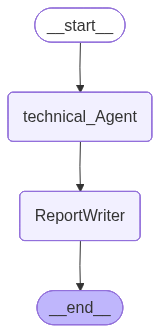

In [109]:
workflow

In [110]:
def parse_json_response(content: str) -> dict:
    match = re.search(r"```(?:json)?\s*(.*?)\s*```", content, re.DOTALL)
    if match:
        content = match.group(1)
    return json.loads(content.strip())

In [115]:
def run_technical_Agent(a:str):
    final_state = workflow.invoke({
        "ticker": a
    })
    
    message = final_state["messages"][-1].content

    finalmessage = parse_json_response(message)

    return finalmessage

In [116]:
a=run_technical_Agent("TCS.NS")

In [117]:
a

{'ticker': 'Unknown',
 'overall_signal': 'Bearish',
 'confidence': 0.8,
 'trend_verdict': "The trend is bearish with a 'bearish' cross signal and a significant gap between the SMA 50 and SMA 200, indicating a strong downtrend. The Bollinger Bands signal is neutral, but the price is near the lower band, suggesting potential oversold conditions.",
 'momentum_verdict': 'Momentum is bearish with an RSI of 37.84, a bearish MACD verdict, and an oversold stochastic signal, indicating strong downward momentum. However, the oversold conditions may suggest a potential reversal.',
 'volume_verdict': "Volume is confirming the downtrend with a 'distribution' OBV trend and a normal volume signal, indicating that smart money is selling and conviction is moderate. The ADL is falling, indicating selling pressure.",
 'volatility_verdict': 'Volatility is high with an ATR of 60.62 and a historical volatility of 0.3876, indicating large daily price swings. The stock is 18.7% below its 52-week high and near